# 04 — Double-Sérsic decomposition

Decompose a galaxy into bulge + disk Sérsic components. Joint fit of all 14 parameters via `MultiLight`.

In [1]:
# Bootstrap: make `lensing` importable when running notebooks/ directly.
import sys
from pathlib import Path
repo = Path.cwd().resolve().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import lensing as gl
# Device-agnostic: prefer MPS (Apple GPU) → CUDA → CPU.
# Pass device="cpu" if you need to force the CPU path (e.g. for
# operators that have no MPS kernel yet, or for reproducibility).
device, dtype = gl.config.setup(seed=42)
print(f"using device: {device}")


/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device: mps


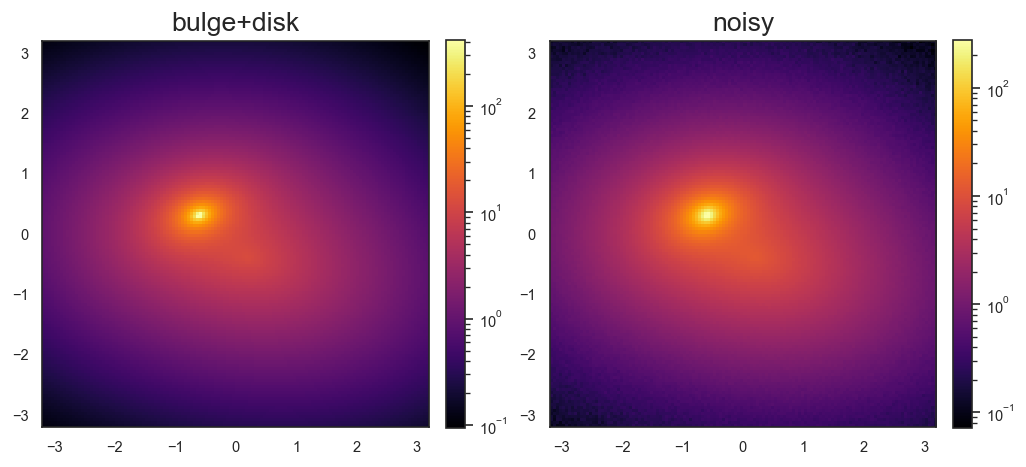

In [2]:
npix, dx = 128, 0.05
xy = gl.data.coordinate_grid(npix=npix, deltapix=dx)

true_a = dict(Ie=8., Re=0.6, n=4.0, x0=-0.6, y0=+0.3, e1=0.15, e2=0.10)
true_b = dict(Ie=2., Re=1.5, n=1.0, x0=+0.2, y0=-0.4, e1=0.20, e2=-0.10)
galaxy = gl.light.DoubleSersic(component1=true_a, component2=true_b)

sigma_n = 0.02
clean, image = gl.data.simulate_image(
    galaxy, xy, psf_fwhm=0.10, deltapix=dx, psf_size=21,
    noise_sigma=sigma_n, seed=2,
)
ext = (-npix*dx/2, npix*dx/2, -npix*dx/2, npix*dx/2)
gl.viz.side_by_side([clean, image], titles=['bulge+disk', 'noisy'],
                    log=True, extent=ext); plt.show()


In [3]:
class DoubleSersicPSF(nn.Module):
    def __init__(self, a, b):
        super().__init__()
        self.galaxy = gl.light.DoubleSersic(component1=a, component2=b)
    def forward(self, xy):
        k = gl.light.gaussian_psf_kernel(0.10, dx, size=21)
        return gl.light.convolve_psf(self.galaxy(xy), k)

init_a = dict(Ie=4., Re=1.0, n=2.5, x0=-0.5, y0=+0.5, e1=0., e2=0.)
init_b = dict(Ie=4., Re=1.0, n=2.5, x0=+0.5, y0=-0.5, e1=0., e2=0.)
model = DoubleSersicPSF(init_a, init_b)

loss = gl.inference.ReducedChiSquared(sigma=sigma_n, n_params=14)
res = gl.inference.fit(
    model, xy, image, loss,
    lr=0.05, epochs=3000,
    scheduler=gl.inference.optimize.reduce_lr_on_plateau(patience=200, factor=0.7),
    grad_clip=10.0, lbfgs_polish=True,
)
print(f"final chi2/dof = {res.best_loss:.4f}")

for i, comp in enumerate(model.galaxy.components):
    print(f"--- component {i+1} ---")
    truth = (true_a, true_b)[i]
    for n_ in ['Ie','Re','n','x0','y0','e1','e2']:
        print(f"  {n_}: true={truth[n_]:+.3f}  fit={float(getattr(comp, n_)):+.3f}")


final chi2/dof = 3.5101
--- component 1 ---
  Ie: true=+8.000  fit=+6.681
  Re: true=+0.600  fit=+0.672
  n: true=+4.000  fit=+4.228
  x0: true=-0.600  fit=-0.600
  y0: true=+0.300  fit=+0.300
  e1: true=+0.150  fit=+0.151
  e2: true=+0.100  fit=+0.099
--- component 2 ---
  Ie: true=+2.000  fit=+1.983
  Re: true=+1.500  fit=+1.457
  n: true=+1.000  fit=+0.997
  x0: true=+0.200  fit=+0.223
  y0: true=-0.400  fit=-0.417
  e1: true=+0.200  fit=+0.203
  e2: true=-0.100  fit=-0.097


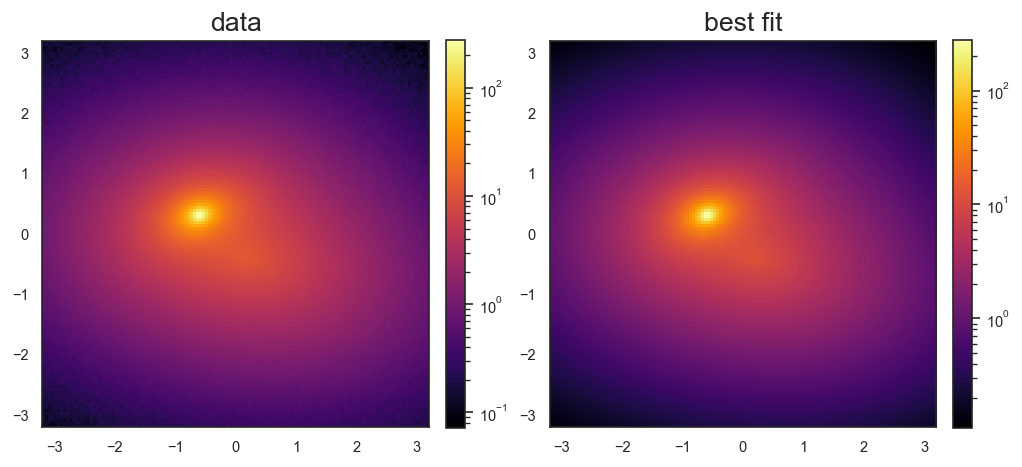

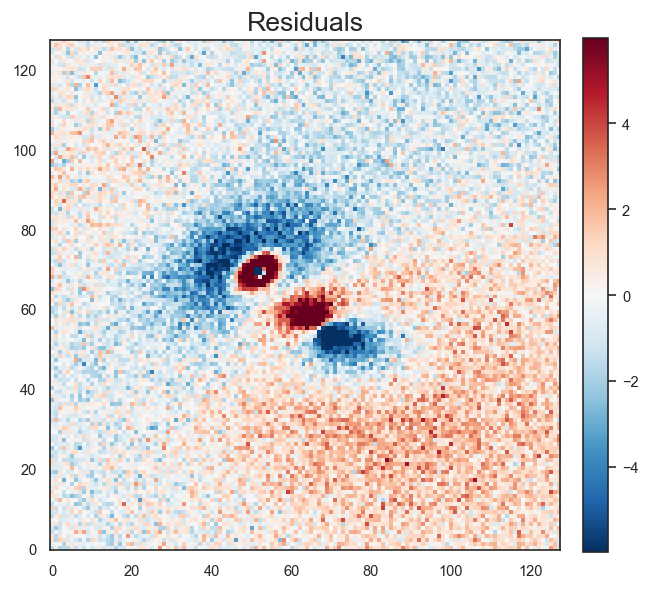

In [4]:
with torch.no_grad():
    pred = model(xy)
gl.viz.side_by_side([image, pred],
                    titles=['data', 'best fit'], log=True, extent=ext); plt.show()
gl.viz.plot_residuals(image, pred, sigma=sigma_n); plt.show()
